<a href="https://colab.research.google.com/github/Vedika-Hore/python-micro-project/blob/main/Task17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
  print(fn)

Saving heart.csv to heart.csv
heart.csv


In [2]:
filepath=('/content/heart.csv')
df=pd.read_csv(filepath)
print(df)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

In [3]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [14]:
df.duplicated().sum()
df=df.drop_duplicates()
print("New Shapes:",df.shape)

New Shapes: (918, 12)


In [41]:
print("Cholesterol ==0 =",(df["Cholesterol"]==0).sum())
print("RestingBP ==0 =",(df["RestingBP"]==0).sum())




Cholesterol ==0 = 172
RestingBP ==0 = 1


In [65]:
print("Before cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

chol_mean=df[df["Cholesterol"] != 0]["Cholesterol"].mean()
print(chol_mean)
BP_mean=df[df["RestingBP"] != 0]["RestingBP"].mean()
print(BP_mean)

df["Cholesterol"]=df["Cholesterol"].replace(0,chol_mean)
df["RestingBP"]=df["RestingBP"].replace(0,BP_mean)

df["Cholesterol"]=df["Cholesterol"].round(2)
df["RestingBP"]=df["RestingBP"].round(2)
print("\n")
print("After cleaning")
print(df[["Cholesterol","RestingBP"]].describe())




Before cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000
244.63625272331154
132.54089324618738


After cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


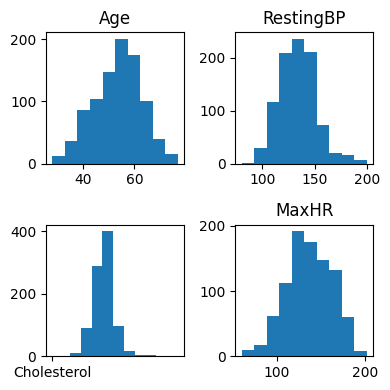

In [71]:
import matplotlib.pyplot as plt
def plot_histograms(df):
  plt.figure(figsize=(4,4))


  plt.subplot(2,2,1)
  plt.hist(df["Age"])
  plt.title("Age")

  plt.subplot(2,2,2)
  plt.hist(df["RestingBP"])
  plt.title("RestingBP")

  plt.subplot(2,2,3)
  plt.hist(df["Cholesterol"])
  plt.hist("Cholesterol")

  plt.subplot(2,2,4)
  plt.hist(df["MaxHR"])
  plt.title("MaxHR")

  plt.tight_layout()

plot_histograms(df)


In [73]:
num_cols=df.select_dtypes(include=['int64','float64'])
num_cols



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140.0,289.0,0,172,0.0,0
1,49,160.0,180.0,0,156,1.0,1
2,37,130.0,283.0,0,98,0.0,0
3,48,138.0,214.0,0,108,1.5,1
4,54,150.0,195.0,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1
914,68,144.0,193.0,1,141,3.4,1
915,57,130.0,131.0,0,115,1.2,1
916,57,130.0,236.0,0,174,0.0,1


In [78]:
cat_cols=df.select_dtypes(include=['object'])
cat_cols

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [84]:
df_encoded=pd.get_dummies(df,columns=["Sex","ChestPainType","FastingBS","RestingECG","ExerciseAngina","ST_Slope"])
print(df_encoded.shape)
print(df_encoded.head())


(918, 22)
   Age  RestingBP  Cholesterol  MaxHR  Oldpeak  HeartDisease  Sex_F  Sex_M  \
0   40      140.0        289.0    172      0.0             0  False   True   
1   49      160.0        180.0    156      1.0             1   True  False   
2   37      130.0        283.0     98      0.0             0  False   True   
3   48      138.0        214.0    108      1.5             1   True  False   
4   54      150.0        195.0    122      0.0             0  False   True   

   ChestPainType_ASY  ChestPainType_ATA  ...  FastingBS_0  FastingBS_1  \
0              False               True  ...         True        False   
1              False              False  ...         True        False   
2              False               True  ...         True        False   
3               True              False  ...         True        False   
4              False              False  ...         True        False   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseAngina_N  \
0  

In [89]:
print("Final Shape=",df_encoded.shape)

print("Final column=")
df_encoded.columns

Final Shape= (918, 22)
Final column=


Index(['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS_0', 'FastingBS_1',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [ ]:
#Question no 1:-
#Ans:-Invalid Zero found:
#Cholesterol=0
#RestringBP=0
#These values were replaced with the mean of the valid (non_zero ) values.


#Question no 2:-
#Ans:-Invalid values can give incorrect analysis and affect machine learning model performane

#Question no 3:-
#One-Hot Encoding converts categorical data into numerical columns so that machine learning algorithms can use them.

#Question no 4:-
# - Missing/invalid values were cleaned.
# - Numerical values became more realistic.
# - Categorical columns were converted into numeric columns.
# - The number of columns increased after One-Hot Encoding.
